### Assignment-01
#### Predict the price of the Uber ride from a given pickup point to the agreed drop-off location. Perform following tasks:
1. Pre-process the dataset.
2. Identify outliers.
3. Check the correlation.
4. Implement linear regression and random forest regression models.
Evaluate the models and compare their respective scores like R2, RMSE, etc.
Dataset link: https://www.kaggle.com/datasets/yasserh/uber-fares-dataset

In [359]:
#import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings 
#We do not want to see warnings
warnings.filterwarnings("ignore") 

In [360]:
#import data
data = pd.read_csv("uber.csv")

In [362]:
#Create a data copy
df = data.copy()

In [363]:
#Print data
df.head

<bound method NDFrame.head of         Unnamed: 0                            key  fare_amount  \
0         24238194    2015-05-07 19:52:06.0000003          7.5   
1         27835199    2009-07-17 20:04:56.0000002          7.7   
2         44984355   2009-08-24 21:45:00.00000061         12.9   
3         25894730    2009-06-26 08:22:21.0000001          5.3   
4         17610152  2014-08-28 17:47:00.000000188         16.0   
...            ...                            ...          ...   
199995    42598914   2012-10-28 10:49:00.00000053          3.0   
199996    16382965    2014-03-14 01:09:00.0000008          7.5   
199997    27804658   2009-06-29 00:42:00.00000078         30.9   
199998    20259894    2015-05-20 14:56:25.0000004         14.5   
199999    11951496   2010-05-15 04:08:00.00000076         14.1   

                pickup_datetime  pickup_longitude  pickup_latitude  \
0       2015-05-07 19:52:06 UTC        -73.999817        40.738354   
1       2009-07-17 20:04:56 UTC      

In [364]:
#Get info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         200000 non-null  int64  
 1   key                200000 non-null  object 
 2   fare_amount        200000 non-null  float64
 3   pickup_datetime    200000 non-null  object 
 4   pickup_longitude   200000 non-null  float64
 5   pickup_latitude    200000 non-null  float64
 6   dropoff_longitude  199999 non-null  float64
 7   dropoff_latitude   199999 non-null  float64
 8   passenger_count    200000 non-null  int64  
dtypes: float64(5), int64(2), object(2)
memory usage: 13.7+ MB


In [365]:
#pickup_datetime is not in required data format
df["pickup_datetime"] = pd.to_datetime(df["pickup_datetime"])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype              
---  ------             --------------   -----              
 0   Unnamed: 0         200000 non-null  int64              
 1   key                200000 non-null  object             
 2   fare_amount        200000 non-null  float64            
 3   pickup_datetime    200000 non-null  datetime64[ns, UTC]
 4   pickup_longitude   200000 non-null  float64            
 5   pickup_latitude    200000 non-null  float64            
 6   dropoff_longitude  199999 non-null  float64            
 7   dropoff_latitude   199999 non-null  float64            
 8   passenger_count    200000 non-null  int64              
dtypes: datetime64[ns, UTC](1), float64(5), int64(2), object(1)
memory usage: 13.7+ MB


In [366]:
#Statistics of data
df.describe()

,Unnamed: 0,fare_amount,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
count,2.000000e+05,200000.000000,200000.000000,200000.000000,199999.000000,199999.000000,200000.000000
mean,2.771250e+07,11.359955,-72.527638,39.935885,-72.525292,39.923890,1.684535
std,1.601382e+07,9.901776,11.437787,7.720539,13.117408,6.794829,1.385997
min,1.000000e+00,-52.000000,-1340.648410,-74.015515,-3356.666300,-881.985513,0.000000
25%,1.382535e+07,6.000000,-73.992065,40.734796,-73.991407,40.733823,1.000000
50%,2.774550e+07,8.500000,-73.981823,40.752592,-73.980093,40.753042,1.000000
75%,4.155530e+07,12.500000,-73.967154,40.767158,-73.963658,40.768001,2.000000
max,5.542357e+07,499.000000,57.418457,1644.421482,1153.572603,872.697628,208.000000


In [367]:
#Number of missing values
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    1
dropoff_latitude     1
passenger_count      0
dtype: int64

In [368]:
#Drop the rows with missing values
df.dropna(inplace=True)
df.isnull().sum()

Unnamed: 0           0
key                  0
fare_amount          0
pickup_datetime      0
pickup_longitude     0
pickup_latitude      0
dropoff_longitude    0
dropoff_latitude     0
passenger_count      0
dtype: int64

In [369]:
#Drop unneccesary rows
df = df.drop(["Unnamed: 0", "key"], axis=1)
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5


In [370]:
#Calculating the ride distance
from math import cos, asin, sqrt, pi
import numpy as np

def distance(lat_1,lon_1,lat_2,lon_2):
#     lat1 = row.pickup_latitude
#     lon1 = row.pickup_longitude
#     lat2 = row.dropoff_latitude
#     lon2 = row.dropoff_longitude
    lon_1, lon_2, lat_1, lat_2 = map(np.radians, [lon_1, lon_2, lat_1, lat_2])  #Degrees to Radians
    
    
    diff_lon = lon_2 - lon_1
    diff_lat = lat_2 - lat_1
    

    km = 2 * 6371 * np.arcsin(np.sqrt(np.sin(diff_lat/2.0)**2 +  np.cos(lat_1) * np.cos(lat_2) * np.sin(diff_lon/2.0)**2))
    
    return km

In [371]:
#Calculating and adding Distance column
temp = distance(df['pickup_latitude'],df['pickup_longitude'],df['dropoff_latitude'],df['dropoff_longitude'])
temp.head()

0    1.683323
1    2.457590
2    5.036377
3    1.661683
4    4.475450
dtype: float64

In [372]:
df_new = df.copy()
df_new['Distance'] = temp
df = df_new
df.head()

,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Distance
0,7.5,2015-05-07 19:52:06+00:00,-73.999817,40.738354,-73.999512,40.723217,1,1.683323
1,7.7,2009-07-17 20:04:56+00:00,-73.994355,40.728225,-73.994710,40.750325,1,2.457590
2,12.9,2009-08-24 21:45:00+00:00,-74.005043,40.740770,-73.962565,40.772647,1,5.036377
3,5.3,2009-06-26 08:22:21+00:00,-73.976124,40.790844,-73.965316,40.803349,3,1.661683
4,16.0,2014-08-28 17:47:00+00:00,-73.925023,40.744085,-73.973082,40.761247,5,4.475450


<Axes: xlabel='Distance'>

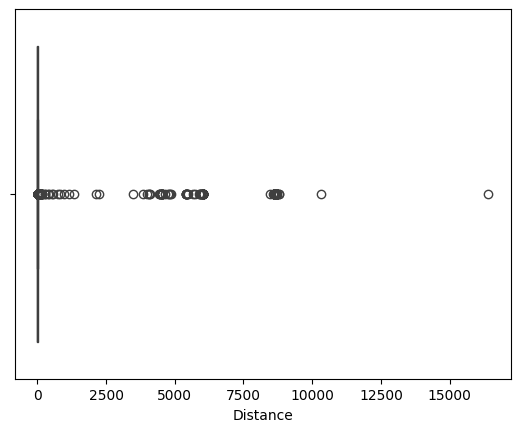

In [373]:
sns.boxplot(data=df,x='Distance')

<Axes: xlabel='fare_amount'>

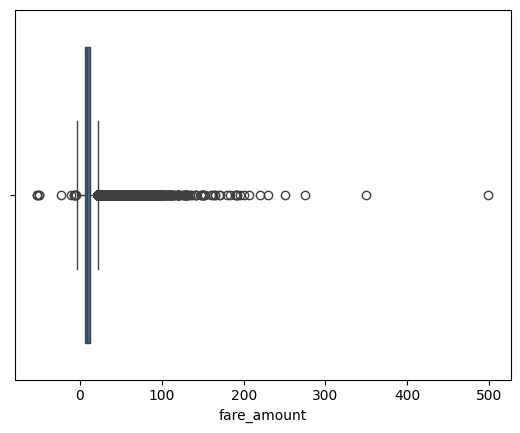

In [374]:
sns.boxplot(data=df,x='fare_amount')

<Axes: xlabel='passenger_count'>

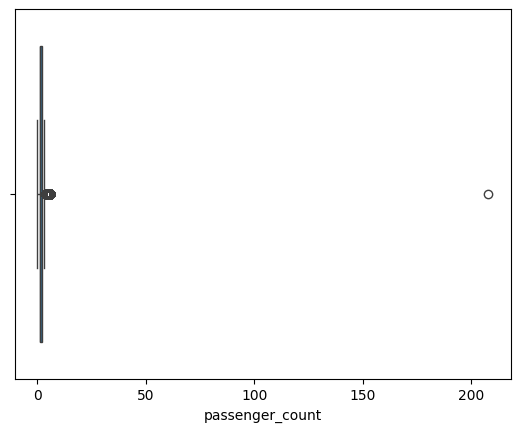

In [375]:
sns.boxplot(data=df,x='passenger_count')

In [376]:
# remove outliers from pickup/dropoff locations
def remove_outliers(feature ):
    global df
    q3 , q1 = np.percentile( df[feature] , [ 75 , 25 ] )
    iqr = q3 - q1
    df = df[ (df[feature] >= q1 - 1.5 * iqr) & (df[feature] <= q3 + 1.5 * iqr) ]
    
remove_outliers("Distance")
remove_outliers("passenger_count")
remove_outliers("fare_amount")


<Axes: xlabel='passenger_count'>

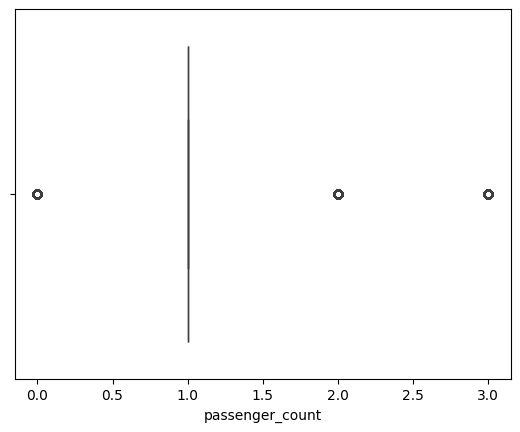

In [377]:
sns.boxplot(data=df,x='passenger_count')

<Axes: xlabel='Distance'>

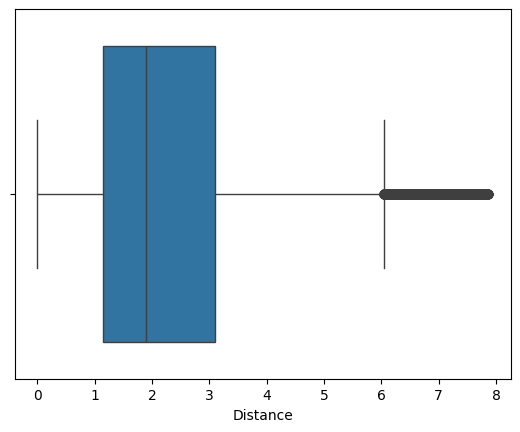

In [378]:
sns.boxplot(data=df,x='Distance')

<Axes: xlabel='fare_amount'>

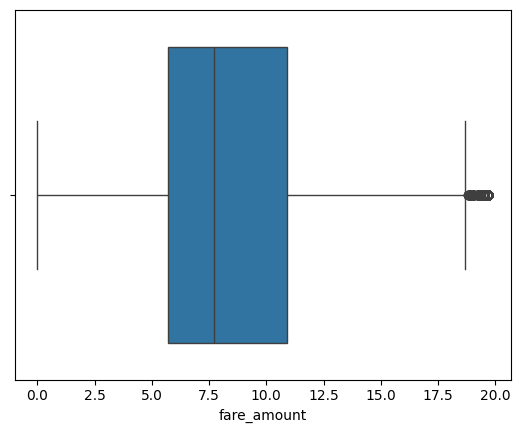

In [379]:
sns.boxplot(data=df,x='fare_amount')

In [380]:
#Extract date and time features from pickup_datetime
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df['week_day'] = df['pickup_datetime'].dt.day_name()
df['Year'] = df['pickup_datetime'].dt.year
df['Month'] = df['pickup_datetime'].dt.month
df['Hour'] = df['pickup_datetime'].dt.hour



In [381]:
# Prepare the data for model training, drop the unnecessary columns
df.drop(columns=['pickup_datetime','pickup_latitude','pickup_longitude','dropoff_latitude','dropoff_longitude'],inplace=True)


In [382]:
df.head()

,fare_amount,passenger_count,Distance,week_day,Year,Month,Hour
0,7.5,1,1.683323,Thursday,2015,5,19
1,7.7,1,2.457590,Friday,2009,7,20
2,12.9,1,5.036377,Monday,2009,8,21
3,5.3,3,1.661683,Friday,2009,6,8
5,4.9,1,0.000000,Saturday,2011,2,2


In [385]:
#Convert categorical values into numbers for model training
temp = df.copy()

def convert_week_day(day):
    if day in ['Monday','Tuesday','Wednesday','Thursday']:
        return 0 # Weekday
    return 1 # Weekend

def convert_hour(hour):
    if 5 <= hour <= 12:
        return 1
    elif 12 < hour <= 17:
        return 2
    elif 17 < hour < 24:
        return 3
    return 0

df['week_day'] = temp['week_day'].apply(convert_week_day)
df['Hour'] = temp['Hour'].apply(convert_hour)
df.head()

,fare_amount,passenger_count,Distance,week_day,Year,Month,Hour
0,7.5,1,1.683323,0,2015,5,3
1,7.7,1,2.457590,1,2009,7,3
2,12.9,1,5.036377,0,2009,8,3
3,5.3,3,1.661683,1,2009,6,1
5,4.9,1,0.000000,1,2011,2,0


In [387]:
#Correlation Analysis
df.corr(method="pearson")

,fare_amount,passenger_count,Distance,week_day,Year,Month,Hour
fare_amount,1.000000,0.019394,0.781964,0.012347,0.142347,0.024776,-0.002774
passenger_count,0.019394,1.000000,0.014101,0.067128,-0.023831,0.006424,0.032538
Distance,0.781964,0.014101,1.000000,0.036489,-0.026992,0.000412,-0.017384
week_day,0.012347,0.067128,0.036489,1.000000,0.008193,-0.007766,-0.076752
Year,0.142347,-0.023831,-0.026992,0.008193,1.000000,-0.115207,0.003604
Month,0.024776,0.006424,0.000412,-0.007766,-0.115207,1.000000,-0.004564
Hour,-0.002774,0.032538,-0.017384,-0.076752,0.003604,-0.004564,1.000000


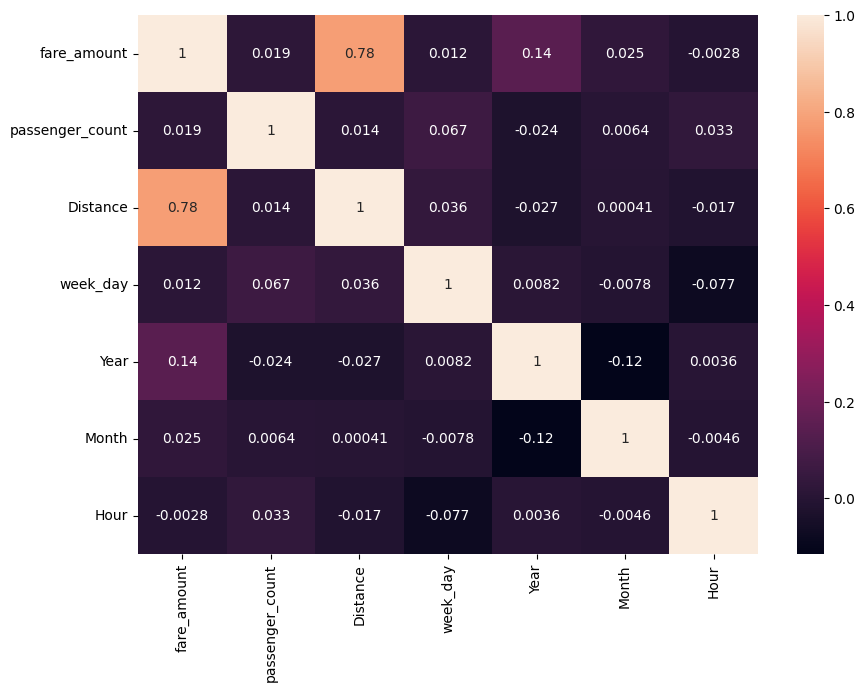

In [388]:
plt.figure(figsize=(10,7))
sns.heatmap(df.corr(), annot=True)
plt.show()

### Linear Regression

In [392]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# train-test split
X = df.drop('fare_amount', axis=1)
y = df['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# standardize the splits
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [393]:
from sklearn.linear_model import LinearRegression

# linear regression model
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

In [396]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

print("R2 score: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))

R2 score:  0.638336210850212
RMSE:  2.2238662386669774
MAE:  1.5990368041603165


### RandomForest

In [397]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X_train_scaled, y_train)

# Predict on the test set
y_pred = model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import r2_score
from sklearn.metrics import root_mean_squared_error,mean_absolute_error

print("R2 score: ", r2_score(y_test, y_pred))
print("RMSE: ", root_mean_squared_error(y_test, y_pred))
print("MAE: ", mean_absolute_error(y_test,y_pred))